In [1]:
import pandas as pd

df = pd.read_csv(
    "/content/amazon_cells_labelled.txt",
    sep="\t",
    header=None,
    names=["review", "label"]
)

df.head()

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Column names:", df.columns.tolist())

Rows: 1000
Columns: 2
Column names: ['review', 'label']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   review  1000 non-null   object
 1   label   1000 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 15.8+ KB


Conclusion: The dataset contains two columns. The review column contains
text, and the label column contains the sentiment category.

In [5]:
class_counts = df["label"].value_counts().sort_index()

print("Negative reviews:", class_counts.get(0, 0))
print("Positive reviews:", class_counts.get(1, 0))

Negative reviews: 500
Positive reviews: 500


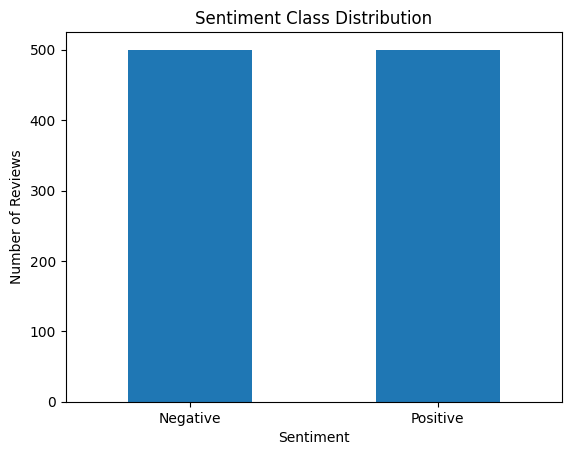

In [6]:
import matplotlib.pyplot as plt

class_counts.index = ["Negative", "Positive"]

class_counts.plot(kind="bar")

plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()

Conclusion: The dataset contains 500 negative reviews and 500 positive
reviews. The classes are balanced.

In [7]:
print("Missing values:")
print(df.isnull().sum())

empty_reviews = df["review"].astype(str).str.strip().eq("").sum()

print("\nEmpty reviews:", empty_reviews)

Missing values:
review    0
label     0
dtype: int64

Empty reviews: 0


Conclusion: The dataset contains 0 missing values and 0 empty reviews.

In [8]:
duplicate_texts = df.duplicated(subset=["review"]).sum()
duplicate_rows = df.duplicated().sum()

print("Duplicate review texts:", duplicate_texts)
print("Completely duplicate rows:", duplicate_rows)

Duplicate review texts: 10
Completely duplicate rows: 10


Conclusion: The dataset contains 10 repeated review texts and 10 fully
duplicated rows. These reviews must be investigated before splitting the
dataset.

In [9]:
df["review_length"] = df["review"].str.split().str.len()

df["review_length"].describe()

,review_length
count,1000.000000
mean,10.246000
std,6.687616
min,1.000000
25%,5.000000
50%,9.000000
75%,15.000000
max,30.000000


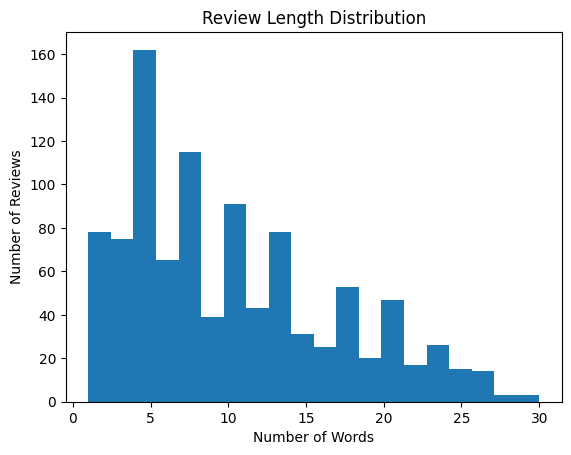

In [10]:
df["review_length"].plot(kind="hist", bins=20)

plt.title("Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Number of Reviews")
plt.show()

Conclusion: The reviews contain different numbers of words. Some reviews
are very short, which may make their sentiment more difficult to understand.

In [11]:
print("Negative examples:")
display(df[df["label"] == 0][["review", "label"]].head(5))

print("Positive examples:")
display(df[df["label"] == 1][["review", "label"]].head(5))

Negative examples:


,review,label
0,So there is no way for me to plug it in here i...,0
3,Tied to charger for conversations lasting more...,0
5,I have to jiggle the plug to get it to line up...,0
6,If you have several dozen or several hundred c...,0
8,"Needless to say, I wasted my money.",0


Positive examples:


,review,label
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
4,The mic is great.,1
7,If you are Razr owner...you must have this!,1
10,And the sound quality is great.,1


In [12]:
df.sort_values("review_length")[
    ["review", "label", "review_length"]
].head(10)

,review,label,review_length
993,disappointed.,0,1
185,Incredible!.,1,1
877,Excellent!.,1,1
777,WORTHWHILE.,1,1
751,disappointing.,0,1
463,Disappointed!.,0,1
39,worthless product.,0,2
973,Lousy product.,0,2
647,Great phone.,1,2
828,Doesn't Work.,0,2


Conclusion: The dataset contains both positive and negative review
sentences. Some reviews are very short or informal and may provide limited
context for the model.

In [13]:
duplicate_examples = (
    df[df.duplicated(subset=["review"], keep=False)]
    .sort_values("review")
)

print("Rows involving repeated review text:", len(duplicate_examples))
display(duplicate_examples.head(20))

Rows involving repeated review text: 20


,review,label,review_length
446,Does not fit.,0,3
748,Does not fit.,0,3
180,Don't buy this product.,0,4
543,Don't buy this product.,0,4
402,Excellent product for the price.,1,5
892,Excellent product for the price.,1,5
792,Great Phone.,1,2
290,Great Phone.,1,2
187,Great phone!.,1,2
285,Great phone!.,1,2


In [14]:
conflicting_reviews = (
    df.groupby("review")["label"]
    .nunique()
    .loc[lambda x: x > 1]
)

print("Review texts with conflicting labels:", len(conflicting_reviews))

if len(conflicting_reviews) > 0:
    display(
        df[df["review"].isin(conflicting_reviews.index)]
        .sort_values("review")
    )

Review texts with conflicting labels: 0


In [15]:
df_clean = df.copy()

# Remove extra spaces at the beginning and end
df_clean["review"] = df_clean["review"].astype(str).str.strip()

initial_rows = len(df_clean)

# Remove empty reviews
empty_count = df_clean["review"].eq("").sum()
df_clean = df_clean[df_clean["review"].ne("")]

# Keep only valid labels
invalid_label_count = (~df_clean["label"].isin([0, 1])).sum()
df_clean = df_clean[df_clean["label"].isin([0, 1])]

# Find review texts that have conflicting labels
conflicting_texts = (
    df_clean.groupby("review")["label"]
    .nunique()
    .loc[lambda x: x > 1]
    .index
)

conflicting_count = len(conflicting_texts)

# Remove conflicting review texts
df_clean = df_clean[
    ~df_clean["review"].isin(conflicting_texts)
]

# Remove repeated copies of the same review
before_duplicates = len(df_clean)

df_clean = (
    df_clean
    .drop_duplicates(subset=["review"], keep="first")
    .reset_index(drop=True)
)

duplicates_removed = before_duplicates - len(df_clean)

print("Original rows:", initial_rows)
print("Empty reviews removed:", empty_count)
print("Invalid labels removed:", invalid_label_count)
print("Conflicting review texts removed:", conflicting_count)
print("Duplicate reviews removed:", duplicates_removed)
print("Final cleaned rows:", len(df_clean))

Original rows: 1000
Empty reviews removed: 0
Invalid labels removed: 0
Conflicting review texts removed: 0
Duplicate reviews removed: 10
Final cleaned rows: 990


Conclusion: Empty or invalid records were removed. Repeated copies of the
same review were removed before splitting to prevent the same sentence from
appearing in both training and test data. Reviews with conflicting labels
were removed because their correct target was unclear.

In [16]:
print("Missing values:")
print(df_clean.isnull().sum())

print("\nEmpty reviews:",
      df_clean["review"].str.strip().eq("").sum())

print("\nDuplicate review texts:",
      df_clean.duplicated(subset=["review"]).sum())

print("\nLabel counts:")
print(df_clean["label"].value_counts().sort_index())

Missing values:
review           0
label            0
review_length    0
dtype: int64

Empty reviews: 0

Duplicate review texts: 0

Label counts:
label
0    497
1    493
Name: count, dtype: int64


In [17]:
short_review_count = (
    df_clean["review"].str.split().str.len() <= 2
).sum()

class_counts_clean = (
    df_clean["label"].value_counts().sort_index()
)

issue_log = pd.DataFrame([
    {
        "Observation": f"{empty_count} empty reviews were found.",
        "Risk": "The model cannot learn from empty text.",
        "Decision": "Remove empty reviews before splitting.",
        "Evidence": "Empty-review check",
        "Status": "Resolved"
    },
    {
        "Observation": f"{duplicates_removed} duplicate reviews were removed.",
        "Risk": "The same review could appear in training and test data.",
        "Decision": "Keep only one copy before splitting.",
        "Evidence": "Duplicate-text check",
        "Status": "Resolved"
    },
    {
        "Observation": f"{conflicting_count} review texts had conflicting labels.",
        "Risk": "The same input would have two different correct answers.",
        "Decision": "Remove conflicting review texts.",
        "Evidence": "Grouped label-count check",
        "Status": "Resolved"
    },
    {
        "Observation": f"{short_review_count} reviews contain two words or fewer.",
        "Risk": "Very short reviews may provide limited context.",
        "Decision": "Keep them and examine them during error analysis.",
        "Evidence": "Review-length analysis",
        "Status": "Open for evaluation"
    },
    {
        "Observation": f"Class counts are {class_counts_clean.to_dict()}.",
        "Risk": "Unequal classes could make accuracy misleading.",
        "Decision": "Use stratified splitting and macro F1.",
        "Evidence": "Class-distribution analysis",
        "Status": "Controlled"
    }
])

display(issue_log)

,Observation,Risk,Decision,Evidence,Status
0,0 empty reviews were found.,The model cannot learn from empty text.,Remove empty reviews before splitting.,Empty-review check,Resolved
1,10 duplicate reviews were removed.,The same review could appear in training and t...,Keep only one copy before splitting.,Duplicate-text check,Resolved
2,0 review texts had conflicting labels.,The same input would have two different correc...,Remove conflicting review texts.,Grouped label-count check,Resolved
3,73 reviews contain two words or fewer.,Very short reviews may provide limited context.,Keep them and examine them during error analysis.,Review-length analysis,Open for evaluation
4,"Class counts are {0: 497, 1: 493}.",Unequal classes could make accuracy misleading.,Use stratified splitting and macro F1.,Class-distribution analysis,Controlled


In [18]:
issue_log.to_csv("/content/issue_log.csv", index=False)

print("Saved: /content/issue_log.csv")

Saved: /content/issue_log.csv


In [19]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# First split: 70% training and 30% temporary
train_df, temp_df = train_test_split(
    df_clean,
    test_size=0.30,
    stratify=df_clean["label"],
    random_state=RANDOM_STATE
)

# Second split: temporary data becomes 15% validation and 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=RANDOM_STATE
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Training rows:", len(train_df))
print("Validation rows:", len(val_df))
print("Test rows:", len(test_df))
print("Total:", len(train_df) + len(val_df) + len(test_df))

Training rows: 693
Validation rows: 148
Test rows: 149
Total: 990


In [20]:
for name, split_df in [
    ("Training", train_df),
    ("Validation", val_df),
    ("Test", test_df)
]:
    print(f"\n{name} set")
    print(split_df["label"].value_counts().sort_index())
    print(split_df["label"].value_counts(normalize=True).sort_index())


Training set
label
0    348
1    345
Name: count, dtype: int64
label
0    0.502165
1    0.497835
Name: proportion, dtype: float64

Validation set
label
0    74
1    74
Name: count, dtype: int64
label
0    0.5
1    0.5
Name: proportion, dtype: float64

Test set
label
0    75
1    74
Name: count, dtype: int64
label
0    0.503356
1    0.496644
Name: proportion, dtype: float64


Conclusion: Stratified splitting preserved approximately the same proportion
of positive and negative reviews in the training, validation and test sets.

In [21]:
train_reviews = set(train_df["review"])
val_reviews = set(val_df["review"])
test_reviews = set(test_df["review"])

print(
    "Train-validation overlap:",
    len(train_reviews.intersection(val_reviews))
)

print(
    "Train-test overlap:",
    len(train_reviews.intersection(test_reviews))
)

print(
    "Validation-test overlap:",
    len(val_reviews.intersection(test_reviews))
)

Train-validation overlap: 0
Train-test overlap: 0
Validation-test overlap: 0


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

pipeline_template = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 1)
        )
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        )
    )
])

pipeline_template

Pipeline(steps=[('tfidf', TfidfVectorizer()),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])